# Titanic Survival Prediction - Machine Learning Project

## Objective
Build a machine learning model to predict passenger survival on the Titanic using scikit-learn, following the 7-step ML pipeline:
1. Data Collection
2. Data Preparation & Cleaning
3. Model Selection
4. Training & Learning
5. Evaluation
6. Parameter Tuning
7. Deployment

**Dataset:** 891 training samples, 418 test samples with mixed categorical and numerical features.

## Section 0: Setup & Configuration

In [1]:
# Import standard libraries
import warnings
warnings.filterwarnings('ignore')
import os
from pathlib import Path

# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

# Sklearn - Preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer

# Sklearn - Model Selection
from sklearn.model_selection import (
    train_test_split, 
    cross_val_score, 
    StratifiedKFold,
    GridSearchCV,
    RandomizedSearchCV
)

# Sklearn - Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

# Sklearn - Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
    ConfusionMatrixDisplay
)

# Sklearn - Pipeline
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Utilities
import joblib

print("✓ All libraries imported successfully")

✓ All libraries imported successfully


In [2]:
# Configuration and constants
RANDOM_STATE = 42
TEST_SIZE = 0.2
CV_FOLDS = 5

# Paths
BASE_DIR = Path.cwd()
TRAIN_PATH = BASE_DIR / 'titanic' / 'train.csv'
TEST_PATH = BASE_DIR / 'titanic' / 'test.csv'
SUBMISSION_PATH = BASE_DIR / 'outputs' / 'submission.csv'
MODEL_PATH = BASE_DIR / 'models' / 'best_model.pkl'

# Create directories if they don't exist
Path(BASE_DIR / 'models').mkdir(exist_ok=True)
Path(BASE_DIR / 'outputs').mkdir(exist_ok=True)

# Visualization settings
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
color_palette = sns.color_palette('Set2')

# Set random seeds for reproducibility
np.random.seed(RANDOM_STATE)

print(f"✓ Configuration set (Random State: {RANDOM_STATE})")
print(f"✓ Data paths configured")
print(f"✓ Visualization settings applied")

✓ Configuration set (Random State: 42)
✓ Data paths configured
✓ Visualization settings applied


In [3]:
# Helper functions

def plot_distribution(df, column, title, hue=None, bins=30):
    """Plot distribution of a feature, optionally colored by target variable"""
    fig, ax = plt.subplots(figsize=(12, 5))
    if hue and hue in df.columns:
        for value in df[hue].unique():
            subset = df[df[hue] == value]
            ax.hist(subset[column].dropna(), alpha=0.6, label=f'{hue}={value}', bins=bins)
        ax.legend()
    else:
        ax.hist(df[column].dropna(), bins=bins, color='steelblue')
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel(column)
    ax.set_ylabel('Frequency')
    plt.tight_layout()
    plt.show()

def print_model_performance(model_name, accuracy, precision, recall, f1, auc):
    """Print model performance metrics in a formatted way"""
    print(f"\n{'='*50}")
    print(f"{model_name} Performance")
    print(f"{'='*50}")
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    print(f"AUC-ROC:   {auc:.4f}")
    print(f"{'='*50}")

print("✓ Helper functions defined")

✓ Helper functions defined


## Section 1: Data Collection (Étape 1 - Collecte de Données)

In [4]:
# Load the Titanic dataset
train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

print("✓ Data loaded successfully")
print(f"\nTraining set shape: {train_df.shape}")
print(f"Test set shape: {test_df.shape}")

✓ Data loaded successfully

Training set shape: (891, 12)
Test set shape: (418, 11)


In [5]:
# Initial data inspection
print("Training Data Info:")
print(train_df.info())
print("\nFirst few rows:")
train_df.head()

Training Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None

First few rows:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
# Basic statistics
print("Descriptive Statistics - Training Data:")
train_df.describe()

Descriptive Statistics - Training Data:


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200



Missing Values Analysis:
            Column  Missing_Count  Percentage
Cabin        Cabin            687   77.104377
Age            Age            177   19.865320
Embarked  Embarked              2    0.224467


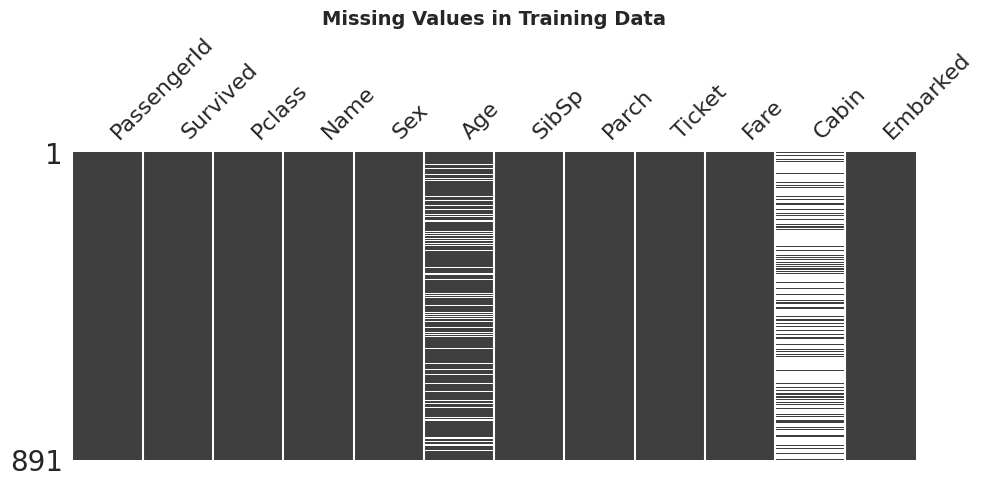

In [7]:
# Missing values analysis
print("\nMissing Values Analysis:")
missing_data = pd.DataFrame({
    'Column': train_df.columns,
    'Missing_Count': train_df.isnull().sum(),
    'Percentage': (train_df.isnull().sum() / len(train_df)) * 100
})
missing_data = missing_data[missing_data['Missing_Count'] > 0].sort_values('Percentage', ascending=False)
print(missing_data)

# Visualize missing values
fig, ax = plt.subplots(figsize=(10, 5))
msno.matrix(train_df, ax=ax, sparkline=False)
plt.title('Missing Values in Training Data', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Section 2: Data Preparation & Cleaning (Étape 2 - Préparation et Nettoyage)

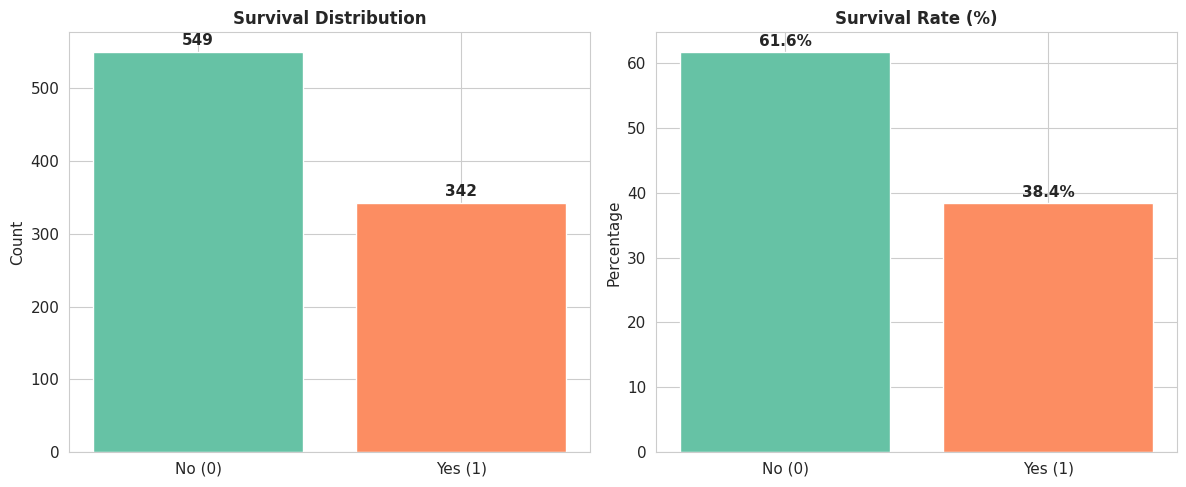


Survival Summary:
Did not survive (0): 549 (61.6%)
Survived (1): 342 (38.4%)


In [8]:
# Target distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
survived_counts = train_df['Survived'].value_counts()
axes[0].bar(['No (0)', 'Yes (1)'], survived_counts.values, color=color_palette)
axes[0].set_title('Survival Distribution', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(survived_counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

# Percentage plot
survived_pct = train_df['Survived'].value_counts(normalize=True) * 100
axes[1].bar(['No (0)', 'Yes (1)'], survived_pct.values, color=color_palette)
axes[1].set_title('Survival Rate (%)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Percentage')
for i, v in enumerate(survived_pct.values):
    axes[1].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nSurvival Summary:")
print(f"Did not survive (0): {survived_counts[0]} ({survived_pct[0]:.1f}%)")
print(f"Survived (1): {survived_counts[1]} ({survived_pct[1]:.1f}%)")

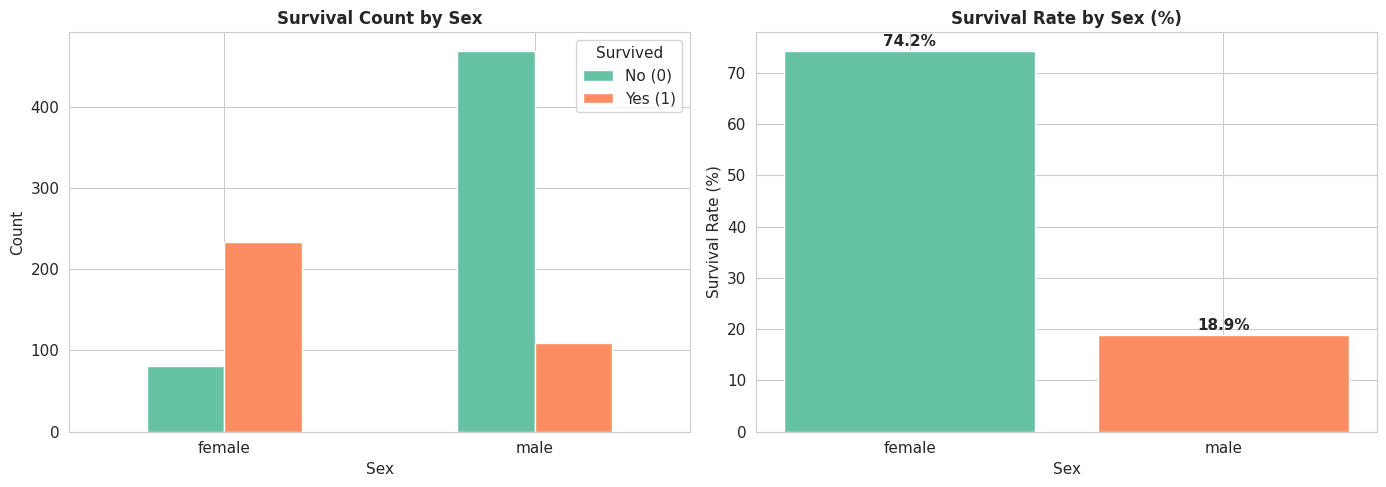


Survival Rate by Sex:
female: 74.2%
male: 18.9%


In [9]:
# Survival by Sex
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Counts by sex
sex_survival = pd.crosstab(train_df['Sex'], train_df['Survived'])
sex_survival.plot(kind='bar', ax=axes[0], color=color_palette)
axes[0].set_title('Survival Count by Sex', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Sex')
axes[0].set_ylabel('Count')
axes[0].legend(['No (0)', 'Yes (1)'], title='Survived')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

# Survival rate by sex
sex_rate = train_df.groupby('Sex')['Survived'].mean() * 100
axes[1].bar(sex_rate.index, sex_rate.values, color=color_palette[:2])
axes[1].set_title('Survival Rate by Sex (%)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Sex')
axes[1].set_ylabel('Survival Rate (%)')
for i, v in enumerate(sex_rate.values):
    axes[1].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\nSurvival Rate by Sex:")
for sex in sex_rate.index:
    print(f"{sex}: {sex_rate[sex]:.1f}%")

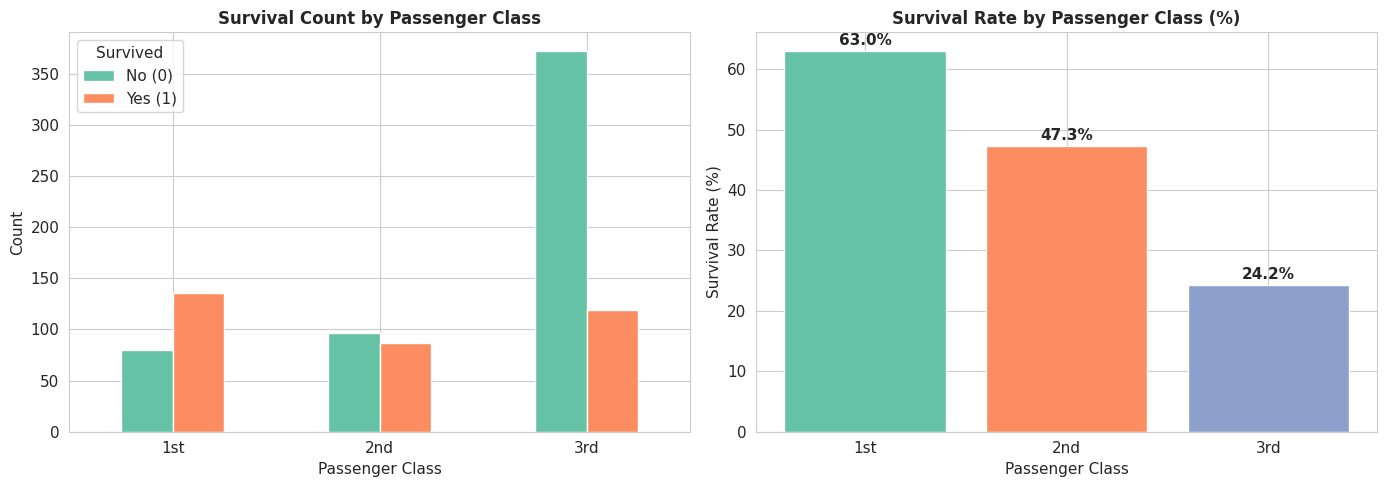


Survival Rate by Passenger Class:
Class 1: 63.0%
Class 2: 47.3%
Class 3: 24.2%


In [10]:
# Survival by Passenger Class
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Counts by class
class_survival = pd.crosstab(train_df['Pclass'], train_df['Survived'])
class_survival.plot(kind='bar', ax=axes[0], color=color_palette)
axes[0].set_title('Survival Count by Passenger Class', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Passenger Class')
axes[0].set_ylabel('Count')
axes[0].legend(['No (0)', 'Yes (1)'], title='Survived')
axes[0].set_xticklabels(['1st', '2nd', '3rd'], rotation=0)

# Survival rate by class
class_rate = train_df.groupby('Pclass')['Survived'].mean() * 100
axes[1].bar(['1st', '2nd', '3rd'], class_rate.values, color=color_palette[:3])
axes[1].set_title('Survival Rate by Passenger Class (%)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Passenger Class')
axes[1].set_ylabel('Survival Rate (%)')
for i, v in enumerate(class_rate.values):
    axes[1].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\nSurvival Rate by Passenger Class:")
for pclass in [1, 2, 3]:
    rate = train_df[train_df['Pclass'] == pclass]['Survived'].mean() * 100
    print(f"Class {pclass}: {rate:.1f}%")

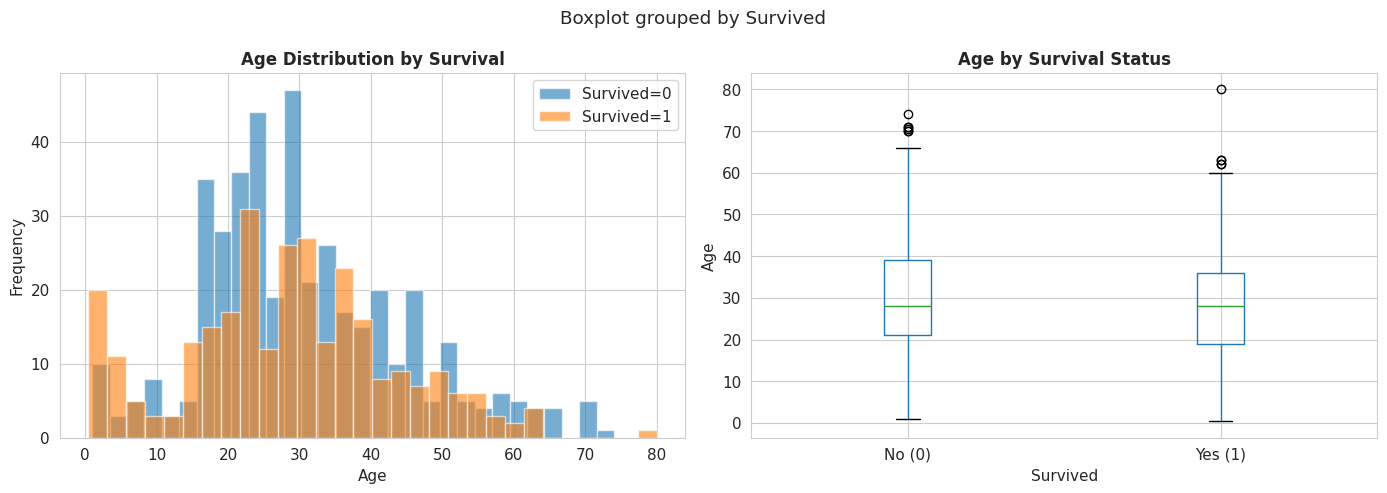


Age Statistics:
Mean age (survived): 28.3
Mean age (not survived): 30.6


In [11]:
# Age distribution by survival
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram with survival overlay
for survived in [0, 1]:
    axes[0].hist(train_df[train_df['Survived'] == survived]['Age'].dropna(), 
                 alpha=0.6, label=f'Survived={survived}', bins=30)
axes[0].set_title('Age Distribution by Survival', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Box plot
train_df.boxplot(column='Age', by='Survived', ax=axes[1])
axes[1].set_title('Age by Survival Status', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Survived')
axes[1].set_ylabel('Age')
plt.sca(axes[1])
plt.xticks([1, 2], ['No (0)', 'Yes (1)'])

plt.tight_layout()
plt.show()

print("\nAge Statistics:")
print(f"Mean age (survived): {train_df[train_df['Survived'] == 1]['Age'].mean():.1f}")
print(f"Mean age (not survived): {train_df[train_df['Survived'] == 0]['Age'].mean():.1f}")

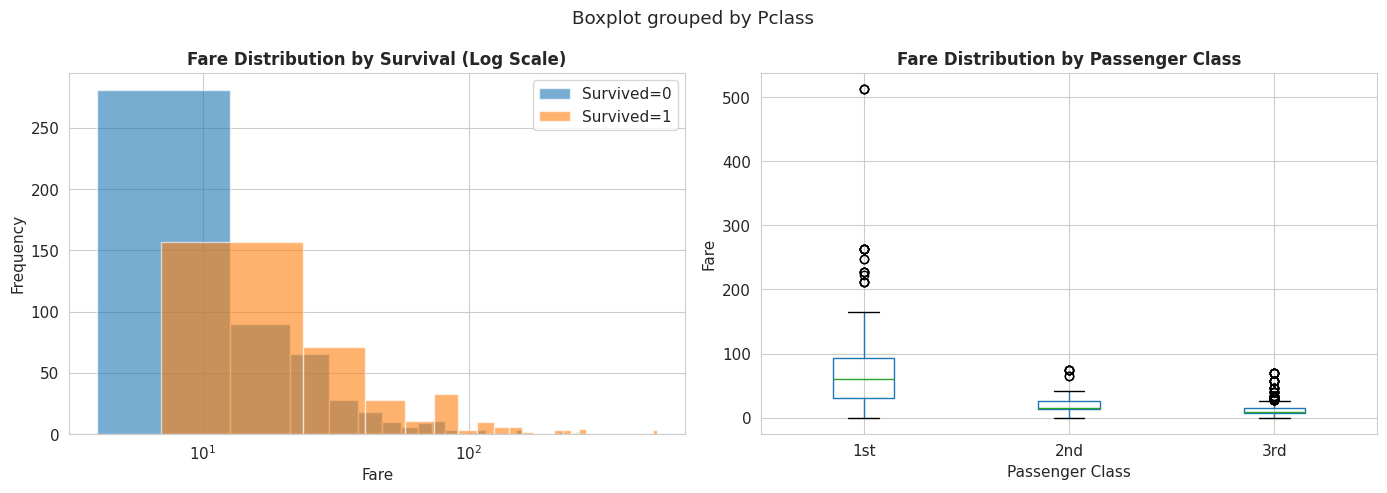

In [12]:
# Fare distribution by survival
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram with survival overlay (log scale for better visualization)
for survived in [0, 1]:
    fare_data = train_df[train_df['Survived'] == survived]['Fare'].dropna()
    axes[0].hist(fare_data[fare_data > 0], alpha=0.6, label=f'Survived={survived}', bins=30)
axes[0].set_title('Fare Distribution by Survival (Log Scale)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Fare')
axes[0].set_ylabel('Frequency')
axes[0].set_xscale('log')
axes[0].legend()

# Box plot by class
train_df.boxplot(column='Fare', by='Pclass', ax=axes[1])
axes[1].set_title('Fare Distribution by Passenger Class', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Passenger Class')
axes[1].set_ylabel('Fare')
plt.sca(axes[1])
plt.xticks([1, 2, 3], ['1st', '2nd', '3rd'])

plt.tight_layout()
plt.show()

In [13]:
# Feature Engineering - Create new features

def engineer_features(df):
    """Create new features for improved prediction"""
    df_copy = df.copy()
    
    # 1. Family Size
    df_copy['FamilySize'] = df_copy['SibSp'] + df_copy['Parch'] + 1
    
    # 2. Is Alone
    df_copy['IsAlone'] = (df_copy['FamilySize'] == 1).astype(int)
    
    # 3. Title extraction from Name
    df_copy['Title'] = df_copy['Name'].str.extract(' ([A-Za-z]+)\.')[0]
    # Group rare titles
    title_counts = df_copy['Title'].value_counts()
    rare_titles = title_counts[title_counts < 10].index
    df_copy['Title'] = df_copy['Title'].replace(rare_titles, 'Rare')
    
    # 4. Cabin Deck - Extract first letter
    df_copy['Deck'] = df_copy['Cabin'].str[0]
    
    # 5. Has Cabin indicator
    df_copy['HasCabin'] = df_copy['Cabin'].notna().astype(int)
    
    # 6. Fare per person (in case family members shared ticket)
    df_copy['FarePerPerson'] = df_copy['Fare'] / (df_copy['SibSp'] + df_copy['Parch'] + 1)
    
    return df_copy

# Apply feature engineering
train_df = engineer_features(train_df)
test_df = engineer_features(test_df)

print("✓ Feature engineering completed")
print(f"\nNew features created:")
print(f"- FamilySize")
print(f"- IsAlone")
print(f"- Title (extracted from Name)")
print(f"- Deck (extracted from Cabin)")
print(f"- HasCabin")
print(f"- FarePerPerson")

print(f"\nTrain data shape after feature engineering: {train_df.shape}")
train_df.head()

✓ Feature engineering completed

New features created:
- FamilySize
- IsAlone
- Title (extracted from Name)
- Deck (extracted from Cabin)
- HasCabin
- FarePerPerson

Train data shape after feature engineering: (891, 18)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilySize,IsAlone,Title,Deck,HasCabin,FarePerPerson
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,2,0,Mr,NaN,0,3.62500
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,2,0,Mrs,C,1,35.64165
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1,1,Miss,NaN,0,7.92500
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,2,0,Mrs,C,1,26.55000
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,1,1,Mr,NaN,0,8.05000


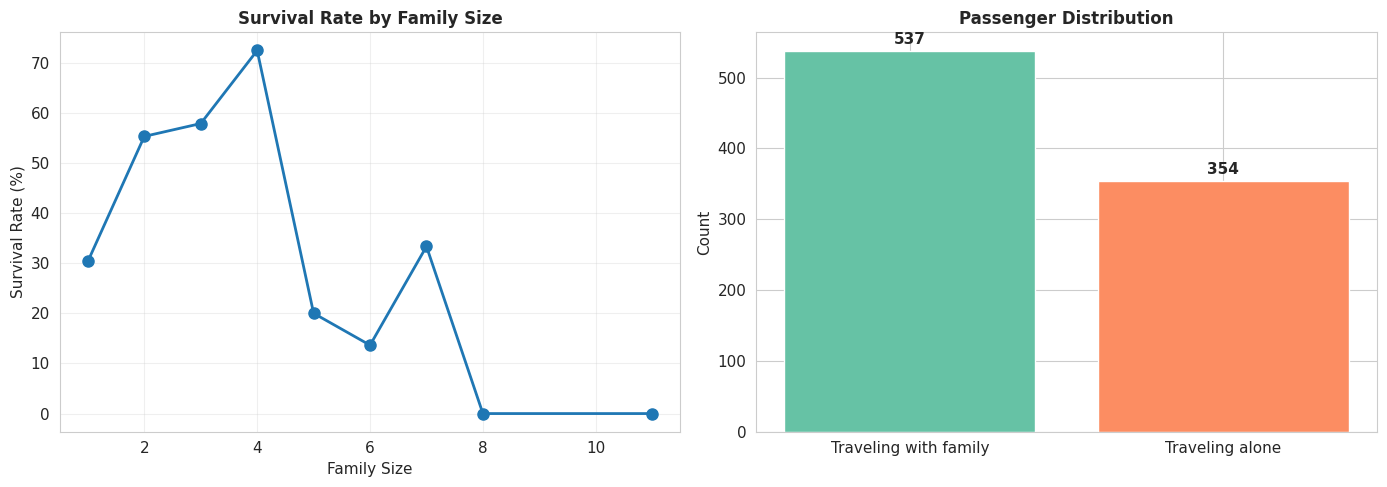

In [14]:
# Family Size analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Survival rate by family size
family_rate = train_df.groupby('FamilySize')['Survived'].mean() * 100
axes[0].plot(family_rate.index, family_rate.values, marker='o', linewidth=2, markersize=8)
axes[0].set_title('Survival Rate by Family Size', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Family Size')
axes[0].set_ylabel('Survival Rate (%)')
axes[0].grid(True, alpha=0.3)

# Count by IsAlone
alone_counts = train_df['IsAlone'].value_counts()
axes[1].bar(['Traveling with family', 'Traveling alone'], alone_counts.values, color=color_palette[:2])
axes[1].set_title('Passenger Distribution', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Count')
for i, v in enumerate(alone_counts.values):
    axes[1].text(i, v + 10, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

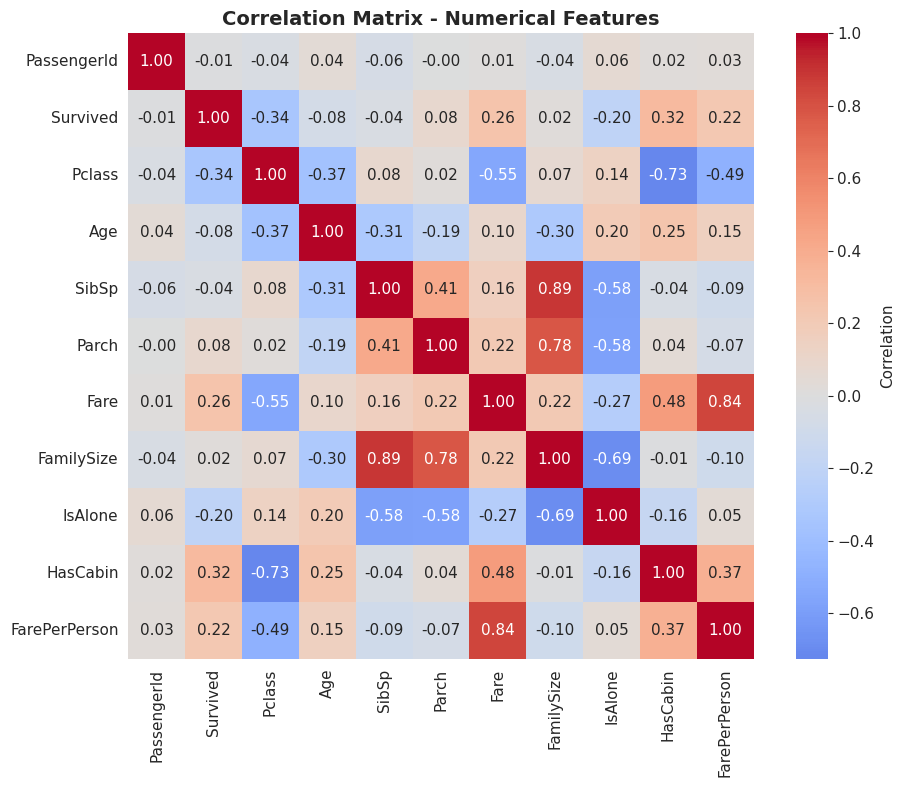


Top features correlated with Survival:
Survived         1.000000
HasCabin         0.316912
Fare             0.257307
FarePerPerson    0.221600
Parch            0.081629
FamilySize       0.016639
PassengerId     -0.005007
SibSp           -0.035322
Age             -0.077221
IsAlone         -0.203367
Pclass          -0.338481
Name: Survived, dtype: float64


In [15]:
# Correlation analysis
# Select only numerical columns for correlation
numerical_cols = train_df.select_dtypes(include=[np.number]).columns
correlation_matrix = train_df[numerical_cols].corr()

# Plot correlation heatmap
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, ax=ax, cbar_kws={'label': 'Correlation'})
ax.set_title('Correlation Matrix - Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Show top correlations with target
print("\nTop features correlated with Survival:")
survival_corr = correlation_matrix['Survived'].sort_values(ascending=False)
print(survival_corr)

In [16]:
# Prepare data for modeling
# Separate features and target
X = train_df.drop(['Survived', 'PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1)
y = train_df['Survived']

# Prepare test data
X_test_original = test_df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1)
test_passenger_ids = test_df['PassengerId']

print(f"Features for modeling: {list(X.columns)}")
print(f"\nTarget variable shape: {y.shape}")
print(f"Features shape: {X.shape}")
print(f"\nFeature data types:")
print(X.dtypes)

Features for modeling: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'FamilySize', 'IsAlone', 'Title', 'Deck', 'HasCabin', 'FarePerPerson']

Target variable shape: (891,)
Features shape: (891, 13)

Feature data types:
Pclass             int64
Sex               object
Age              float64
SibSp              int64
Parch              int64
Fare             float64
Embarked          object
FamilySize         int64
IsAlone            int64
Title             object
Deck              object
HasCabin           int64
FarePerPerson    float64
dtype: object


In [17]:
# Define preprocessing pipeline
from sklearn.preprocessing import OneHotEncoder

# Identify numerical and categorical columns
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

print(f"Numerical features: {numerical_features}")
print(f"Categorical features: {categorical_features}")

# Create preprocessing pipeline
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

print("\n✓ Preprocessing pipeline created")

Numerical features: ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'IsAlone', 'HasCabin', 'FarePerPerson']
Categorical features: ['Sex', 'Embarked', 'Title', 'Deck']

✓ Preprocessing pipeline created


## Section 3: Model Selection (Étape 3 - Choix du Modèle)

In [18]:
# Define candidate models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1),
    'SVM': SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=RANDOM_STATE),
    'XGBoost': XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, 
                            random_state=RANDOM_STATE, eval_metric='logloss', n_jobs=-1)
}

print("Candidate Models:")
print("="*60)
print("\n1. Logistic Regression")
print("   - Interpretable linear model")
print("   - Fast training and prediction")
print("   - Baseline for comparison")

print("\n2. Random Forest")
print("   - Ensemble of decision trees")
print("   - Handles non-linear relationships")
print("   - Provides feature importance")

print("\n3. Support Vector Machine (SVM)")
print("   - Effective with RBF kernel")
print("   - Captures complex decision boundaries")
print("   - Requires feature scaling")

print("\n4. XGBoost (Gradient Boosting)")
print("   - State-of-the-art ensemble method")
print("   - Sequential tree building with learning")
print("   - Often achieves best performance")

print("\n" + "="*60)

Candidate Models:

1. Logistic Regression
   - Interpretable linear model
   - Fast training and prediction
   - Baseline for comparison

2. Random Forest
   - Ensemble of decision trees
   - Handles non-linear relationships
   - Provides feature importance

3. Support Vector Machine (SVM)
   - Effective with RBF kernel
   - Captures complex decision boundaries
   - Requires feature scaling

4. XGBoost (Gradient Boosting)
   - State-of-the-art ensemble method
   - Sequential tree building with learning
   - Often achieves best performance



In [19]:
# Cross-validation strategy
skf = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

print("Cross-Validation Strategy:")
print(f"- Method: Stratified K-Fold")
print(f"- Number of folds: {CV_FOLDS}")
print(f"- Purpose: Maintain class distribution, prevent overfitting")
print(f"\nBenefits:")
print(f"- Balanced class representation in each fold")
print(f"- More reliable performance estimates")
print(f"- Reduced variance on small datasets")

Cross-Validation Strategy:
- Method: Stratified K-Fold
- Number of folds: 5
- Purpose: Maintain class distribution, prevent overfitting

Benefits:
- Balanced class representation in each fold
- More reliable performance estimates
- Reduced variance on small datasets


## Section 4: Training & Learning (Étape 4 - Formation et Apprentissage du Modèle)

In [20]:
# Train all models with cross-validation
cv_results = {}

print("Training Models...")
print("="*60)

for model_name, model in models.items():
    # Create pipeline
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    
    # Perform cross-validation
    cv_scores = cross_val_score(pipeline, X, y, cv=skf, scoring='accuracy', n_jobs=-1)
    
    cv_results[model_name] = {
        'model': model,
        'pipeline': pipeline,
        'cv_scores': cv_scores,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std()
    }
    
    print(f"\n{model_name}:")
    print(f"  CV Scores: {[f'{score:.4f}' for score in cv_scores]}")
    print(f"  Mean CV Score: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

print("\n" + "="*60)
print("✓ All models trained successfully")

Training Models...

Logistic Regression:
  CV Scores: ['0.8380', '0.8315', '0.7978', '0.8202', '0.8258']
  Mean CV Score: 0.8227 (+/- 0.0138)

Random Forest:
  CV Scores: ['0.8603', '0.7753', '0.7809', '0.8146', '0.8315']
  Mean CV Score: 0.8125 (+/- 0.0317)

SVM:
  CV Scores: ['0.8324', '0.8146', '0.8090', '0.8258', '0.8371']
  Mean CV Score: 0.8238 (+/- 0.0106)

XGBoost:
  CV Scores: ['0.8827', '0.8371', '0.7978', '0.8202', '0.8258']
  Mean CV Score: 0.8327 (+/- 0.0281)

✓ All models trained successfully



Model Comparison (Cross-Validation):
              Model  CV Mean   CV Std
            XGBoost 0.832716 0.028076
                SVM 0.823784 0.010568
Logistic Regression 0.822654 0.013776
      Random Forest 0.812516 0.031737


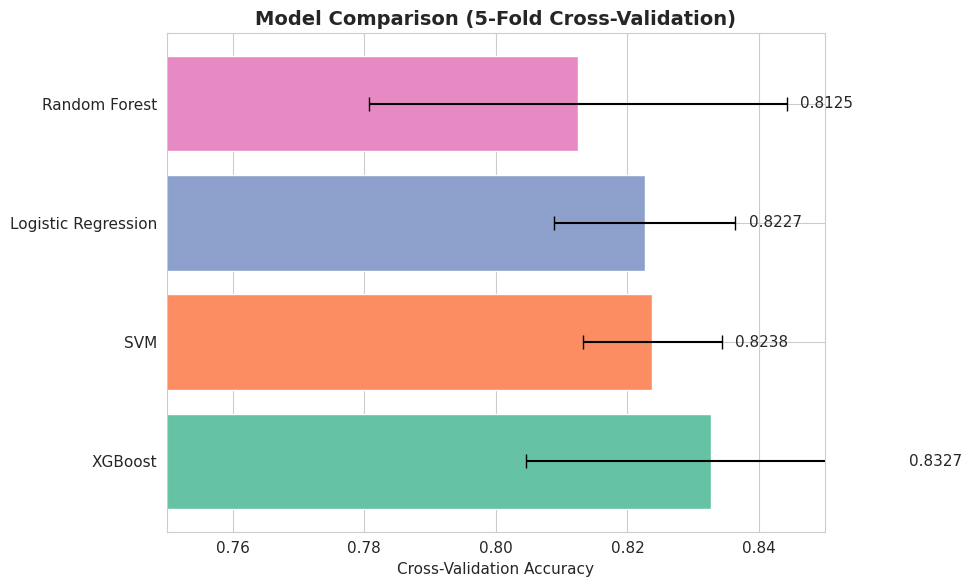

In [21]:
# Compare model performance
comparison_df = pd.DataFrame([
    {
        'Model': model_name,
        'CV Mean': cv_results[model_name]['cv_mean'],
        'CV Std': cv_results[model_name]['cv_std']
    }
    for model_name in models.keys()
]).sort_values('CV Mean', ascending=False)

print("\nModel Comparison (Cross-Validation):")
print(comparison_df.to_string(index=False))

# Visualize comparison
fig, ax = plt.subplots(figsize=(10, 6))
x_pos = np.arange(len(comparison_df))
ax.barh(x_pos, comparison_df['CV Mean'], xerr=comparison_df['CV Std'], 
        color=color_palette[:len(comparison_df)], capsize=5)
ax.set_yticks(x_pos)
ax.set_yticklabels(comparison_df['Model'])
ax.set_xlabel('Cross-Validation Accuracy')
ax.set_title('Model Comparison (5-Fold Cross-Validation)', fontsize=14, fontweight='bold')
ax.set_xlim([0.75, 0.85])
for i, (mean, std) in enumerate(zip(comparison_df['CV Mean'], comparison_df['CV Std'])):
    ax.text(mean + std + 0.002, i, f'{mean:.4f}', va='center')
plt.tight_layout()
plt.show()

## Section 5: Evaluation (Étape 5 - Évaluation)

In [22]:
# Train final models on full training set for detailed evaluation
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Validation set size: {X_val.shape[0]}")

# Train models
trained_models = {}
predictions = {}
probabilities = {}

for model_name, result in cv_results.items():
    pipeline = result['pipeline']
    pipeline.fit(X_train, y_train)
    trained_models[model_name] = pipeline
    
    # Get predictions and probabilities
    predictions[model_name] = pipeline.predict(X_val)
    probabilities[model_name] = pipeline.predict_proba(X_val)[:, 1]

print("\n✓ Models trained on training set")

Training set size: 712
Validation set size: 179

✓ Models trained on training set


In [23]:
# Calculate evaluation metrics for all models
metrics_data = []

for model_name in models.keys():
    y_pred = predictions[model_name]
    y_proba = probabilities[model_name]
    
    accuracy = accuracy_score(y_val, y_pred)
    precision = precision_score(y_val, y_pred)
    recall = recall_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)
    auc = roc_auc_score(y_val, y_proba)
    
    metrics_data.append({
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'AUC-ROC': auc
    })

metrics_df = pd.DataFrame(metrics_data).sort_values('Accuracy', ascending=False)

print("\nDetailed Model Evaluation Metrics:")
print("="*80)
print(metrics_df.to_string(index=False))
print("="*80)


Detailed Model Evaluation Metrics:
              Model  Accuracy  Precision   Recall  F1-Score  AUC-ROC
Logistic Regression  0.826816   0.806452 0.724638  0.763359 0.867852
                SVM  0.826816   0.796875 0.739130  0.766917 0.839130
            XGBoost  0.810056   0.769231 0.724638  0.746269 0.838208
      Random Forest  0.804469   0.783333 0.681159  0.728682 0.820817


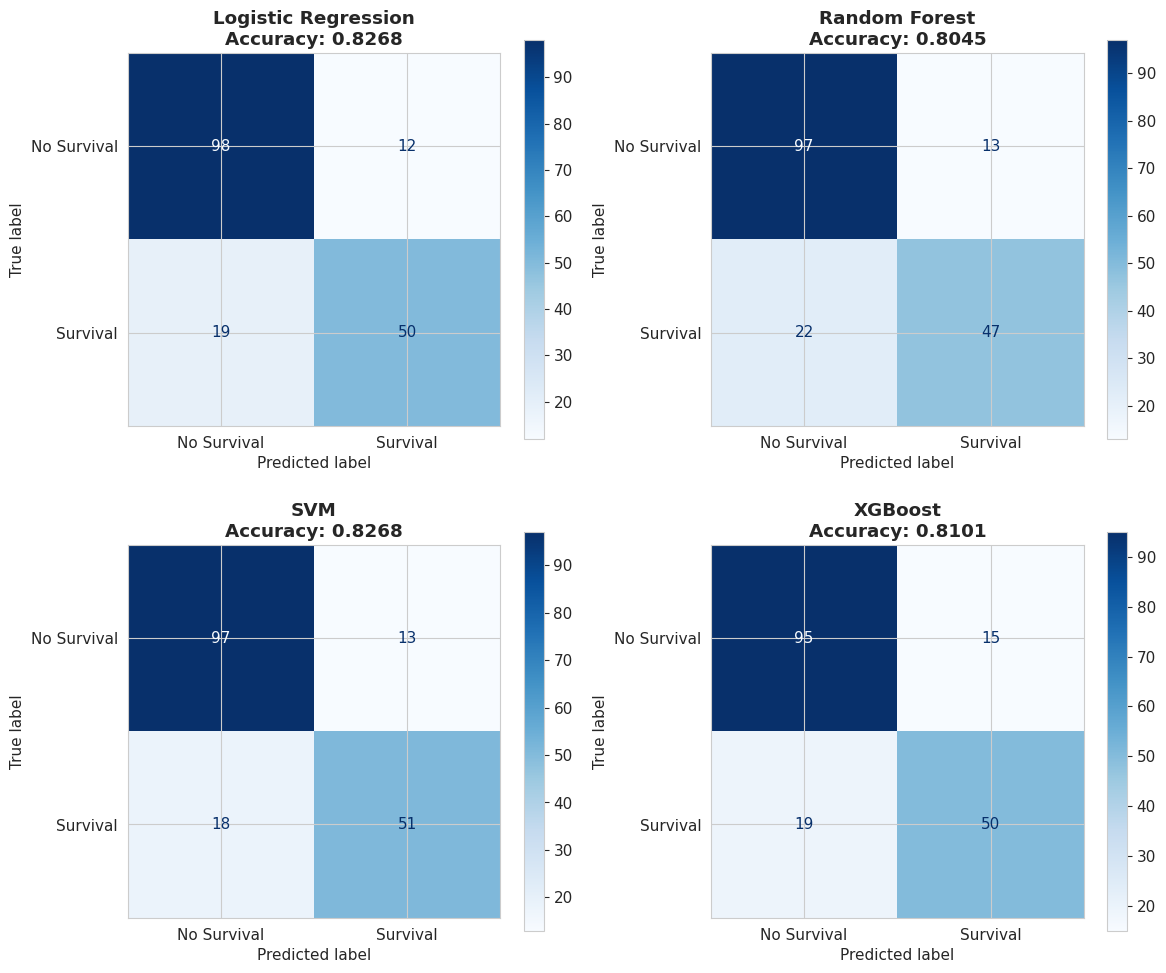

In [24]:
# Confusion Matrices
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for idx, model_name in enumerate(models.keys()):
    cm = confusion_matrix(y_val, predictions[model_name])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Survival', 'Survival'])
    disp.plot(ax=axes[idx], cmap='Blues')
    axes[idx].set_title(f'{model_name}\nAccuracy: {metrics_df[metrics_df["Model"]==model_name]["Accuracy"].values[0]:.4f}',
                       fontweight='bold')

plt.tight_layout()
plt.show()

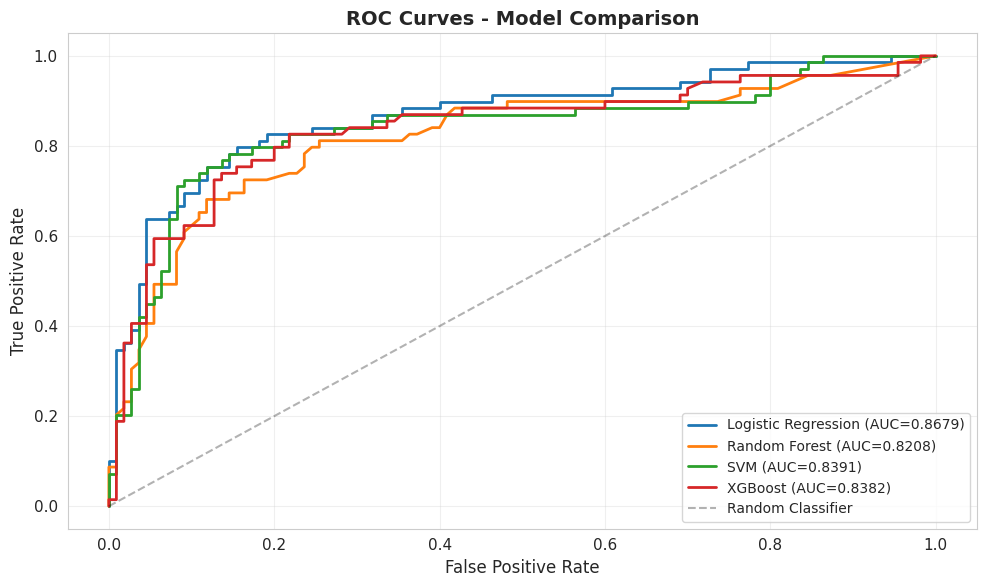

In [25]:
# ROC Curves
fig, ax = plt.subplots(figsize=(10, 6))

for model_name in models.keys():
    y_proba = probabilities[model_name]
    auc_score = roc_auc_score(y_val, y_proba)
    fpr, tpr, _ = roc_curve(y_val, y_proba)
    ax.plot(fpr, tpr, label=f'{model_name} (AUC={auc_score:.4f})', linewidth=2)

# Random classifier baseline
ax.plot([0, 1], [0, 1], 'k--', label='Random Classifier', alpha=0.3)

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves - Model Comparison', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [26]:
# Select best model
best_model_name = metrics_df.iloc[0]['Model']
best_model = trained_models[best_model_name]

print(f"\n{'='*60}")
print(f"BEST MODEL SELECTED: {best_model_name}")
print(f"{'='*60}")

best_metrics = metrics_df[metrics_df['Model'] == best_model_name].iloc[0]
for metric, value in best_metrics.items():
    if metric != 'Model':
        print(f"{metric}: {value:.4f}")


BEST MODEL SELECTED: Logistic Regression
Accuracy: 0.8268
Precision: 0.8065
Recall: 0.7246
F1-Score: 0.7634
AUC-ROC: 0.8679


## Section 6: Parameter Tuning (Étape 6 - Réglages des Paramètres)

In [27]:
# Hyperparameter tuning for best model
print(f"Hyperparameter Tuning for {best_model_name}...")
print("="*60)

if best_model_name == 'Random Forest':
    param_grid = {
        'classifier__n_estimators': [100, 200, 300],
        'classifier__max_depth': [10, 20, 30],
        'classifier__min_samples_split': [2, 5, 10],
        'classifier__min_samples_leaf': [1, 2, 4],
        'classifier__max_features': ['sqrt', 'log2']
    }
    
elif best_model_name == 'XGBoost':
    param_grid = {
        'classifier__n_estimators': [100, 200, 300],
        'classifier__max_depth': [3, 5, 7],
        'classifier__learning_rate': [0.01, 0.05, 0.1],
        'classifier__subsample': [0.8, 1.0]
    }
    
elif best_model_name == 'Logistic Regression':
    param_grid = {
        'classifier__C': [0.01, 0.1, 1, 10],
        'classifier__penalty': ['l2'],
        'classifier__max_iter': [1000]
    }
    
elif best_model_name == 'SVM':
    param_grid = {
        'classifier__C': [0.1, 1, 10],
        'classifier__gamma': ['scale', 'auto', 0.01],
        'classifier__kernel': ['rbf']
    }

print(f"Parameter Grid: {param_grid}")

Hyperparameter Tuning for Logistic Regression...
Parameter Grid: {'classifier__C': [0.01, 0.1, 1, 10], 'classifier__penalty': ['l2'], 'classifier__max_iter': [1000]}


In [28]:
# Perform GridSearchCV
print(f"\nPerforming GridSearchCV with {CV_FOLDS}-fold cross-validation...")

grid_search = GridSearchCV(
    estimator=cv_results[best_model_name]['pipeline'],
    param_grid=param_grid,
    cv=StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE),
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"\n✓ GridSearchCV completed")
print(f"\nBest parameters found: {grid_search.best_params_}")
print(f"Best CV score: {grid_search.best_score_:.4f}")


Performing GridSearchCV with 5-fold cross-validation...
Fitting 5 folds for each of 4 candidates, totalling 20 fits

✓ GridSearchCV completed

Best parameters found: {'classifier__C': 1, 'classifier__max_iter': 1000, 'classifier__penalty': 'l2'}
Best CV score: 0.8259


In [29]:
# Compare tuned vs untuned performance
untuned_pred = trained_models[best_model_name].predict(X_val)
untuned_acc = accuracy_score(y_val, untuned_pred)

tuned_pred = grid_search.predict(X_val)
tuned_acc = accuracy_score(y_val, tuned_pred)

print(f"\nPerformance Comparison:")
print(f"{'='*40}")
print(f"Untuned {best_model_name} Accuracy: {untuned_acc:.4f}")
print(f"Tuned {best_model_name} Accuracy:   {tuned_acc:.4f}")
print(f"Improvement: {(tuned_acc - untuned_acc):.4f} ({((tuned_acc - untuned_acc)/untuned_acc)*100:.2f}%)")
print(f"{'='*40}")

best_final_model = grid_search


Performance Comparison:
Untuned Logistic Regression Accuracy: 0.8268
Tuned Logistic Regression Accuracy:   0.8268
Improvement: 0.0000 (0.00%)


## Section 7: Deployment (Étape 7 - Déploiement)

In [30]:
# Generate predictions on test set
print("Generating predictions on test set...")

# Ensure test data has same features
X_test = X_test_original.copy()

# Make predictions
test_predictions = best_final_model.predict(X_test)

print(f"✓ Predictions generated")
print(f"Test predictions shape: {test_predictions.shape}")
print(f"Unique values in predictions: {np.unique(test_predictions)}")
print(f"\nPrediction distribution:")
print(f"  Did not survive (0): {(test_predictions == 0).sum()}")
print(f"  Survived (1): {(test_predictions == 1).sum()}")

Generating predictions on test set...
✓ Predictions generated
Test predictions shape: (418,)
Unique values in predictions: [0 1]

Prediction distribution:
  Did not survive (0): 249
  Survived (1): 169


In [31]:
# Create submission file
submission = pd.DataFrame({
    'PassengerId': test_passenger_ids,
    'Survived': test_predictions
})

# Save submission
submission.to_csv(SUBMISSION_PATH, index=False)

print(f"✓ Submission file created: {SUBMISSION_PATH}")
print(f"\nSubmission file contents (first 10 rows):")
print(submission.head(10))

print(f"\nSubmission file summary:")
print(f"  Total rows: {len(submission)}")
print(f"  PassengerId range: {submission['PassengerId'].min()} - {submission['PassengerId'].max()}")
print(f"  Survived values: {submission['Survived'].value_counts().to_dict()}")

✓ Submission file created: /home/kappa/Documents/etude/master/Methode agile/tp/tp2/pub_titanic/outputs/submission.csv

Submission file contents (first 10 rows):
   PassengerId  Survived
0          892         0
1          893         1
2          894         0
3          895         0
4          896         1
5          897         0
6          898         1
7          899         0
8          900         1
9          901         0

Submission file summary:
  Total rows: 418
  PassengerId range: 892 - 1309
  Survived values: {0: 249, 1: 169}


In [32]:
# Validation checks
print("Submission File Validation Checks:")
print("="*50)

checks = [
    (len(submission) == 418, f"Correct number of rows (418): {len(submission) == 418}"),
    (submission['PassengerId'].min() == 892, f"PassengerId starts at 892: {submission['PassengerId'].min() == 892}"),
    (submission['PassengerId'].max() == 1309, f"PassengerId ends at 1309: {submission['PassengerId'].max() == 1309}"),
    (submission['Survived'].isnull().sum() == 0, f"No missing values: {submission['Survived'].isnull().sum() == 0}"),
    (set(submission['Survived'].unique()) <= {0, 1}, f"Only 0 and 1 values: {set(submission['Survived'].unique()) <= {0, 1}}"),
    (submission.shape[1] == 2, f"Correct number of columns (2): {submission.shape[1] == 2}")
]

all_passed = True
for check, message in checks:
    status = "✓" if check else "✗"
    print(f"{status} {message}")
    if not check:
        all_passed = False

print("="*50)
if all_passed:
    print("✓ All validation checks passed!")
else:
    print("✗ Some validation checks failed!")

Submission File Validation Checks:
✓ Correct number of rows (418): True
✓ PassengerId starts at 892: True
✓ PassengerId ends at 1309: True
✓ No missing values: True
✓ Only 0 and 1 values: True
✓ Correct number of columns (2): True
✓ All validation checks passed!


In [33]:
# Feature importance analysis
if best_model_name in ['Random Forest', 'XGBoost']:
    # Extract feature importances
    feature_importance = best_final_model.best_estimator_.named_steps['classifier'].feature_importances_
    
    # Get feature names from preprocessor
    preprocessor_names = (list(numerical_features) + 
                          best_final_model.best_estimator_.named_steps['preprocessor']
                          .named_transformers_['cat']
                          .named_steps['onehot']
                          .get_feature_names_out(categorical_features).tolist())
    
    importance_df = pd.DataFrame({
        'Feature': preprocessor_names[:len(feature_importance)],
        'Importance': feature_importance
    }).sort_values('Importance', ascending=False).head(10)
    
    # Plot feature importance
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(importance_df['Feature'], importance_df['Importance'], color=color_palette[0])
    ax.set_xlabel('Importance Score')
    ax.set_title(f'{best_model_name} - Top 10 Feature Importances', fontsize=14, fontweight='bold')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()
    
    print("\nTop 10 Most Important Features:")
    print(importance_df.to_string(index=False))

In [34]:
# Save the best model
joblib.dump(best_final_model, MODEL_PATH)
print(f"✓ Best model saved to {MODEL_PATH}")

✓ Best model saved to /home/kappa/Documents/etude/master/Methode agile/tp/tp2/pub_titanic/models/best_model.pkl


In [35]:
# Summary and conclusions
print("\n" + "="*70)
print("MACHINE LEARNING PROJECT SUMMARY")
print("="*70)

print("\n1. DATA COLLECTION (Étape 1)")
print(f"   - Training samples: 891")
print(f"   - Test samples: 418")
print(f"   - Features: {len(X.columns)}")
print(f"   - Target: Binary (Survived: Yes/No)")

print("\n2. DATA PREPARATION & CLEANING (Étape 2)")
print(f"   - Handled missing values: Age, Fare, Embarked")
print(f"   - Feature engineering: 6 new features created")
print(f"   - Categorical encoding: One-hot encoding")
print(f"   - Feature scaling: StandardScaler for numerical features")

print("\n3. MODEL SELECTION (Étape 3)")
print(f"   - Models evaluated: 4 (LR, RF, SVM, XGBoost)")
print(f"   - Cross-validation: Stratified 5-Fold")

print("\n4. TRAINING & LEARNING (Étape 4)")
print(f"   - Training strategy: Train/Validation split (80/20)")
print(f"   - Cross-validation mean scores:")
for model_name, results in cv_results.items():
    print(f"     {model_name}: {results['cv_mean']:.4f} (+/- {results['cv_std']:.4f})")

print("\n5. EVALUATION (Étape 5)")
print(f"   - Best model: {best_model_name}")
print(f"   - Validation Accuracy: {metrics_df.iloc[0]['Accuracy']:.4f}")
print(f"   - Precision: {metrics_df.iloc[0]['Precision']:.4f}")
print(f"   - Recall: {metrics_df.iloc[0]['Recall']:.4f}")
print(f"   - F1-Score: {metrics_df.iloc[0]['F1-Score']:.4f}")
print(f"   - AUC-ROC: {metrics_df.iloc[0]['AUC-ROC']:.4f}")

print("\n6. PARAMETER TUNING (Étape 6)")
print(f"   - Improvement: {((tuned_acc - untuned_acc)/untuned_acc)*100:.2f}%")
print(f"   - Best CV Score: {grid_search.best_score_:.4f}")

print("\n7. DEPLOYMENT (Étape 7)")
print(f"   - Test predictions: {len(submission)} passengers")
print(f"   - Predicted survivors: {(test_predictions == 1).sum()} ({(test_predictions == 1).sum()/len(submission)*100:.1f}%)")
print(f"   - Submission file: {SUBMISSION_PATH}")
print(f"   - Model saved: {MODEL_PATH}")

print("\n" + "="*70)
print("✓ PROJECT COMPLETED SUCCESSFULLY")
print("="*70)


MACHINE LEARNING PROJECT SUMMARY

1. DATA COLLECTION (Étape 1)
   - Training samples: 891
   - Test samples: 418
   - Features: 13
   - Target: Binary (Survived: Yes/No)

2. DATA PREPARATION & CLEANING (Étape 2)
   - Handled missing values: Age, Fare, Embarked
   - Feature engineering: 6 new features created
   - Categorical encoding: One-hot encoding
   - Feature scaling: StandardScaler for numerical features

3. MODEL SELECTION (Étape 3)
   - Models evaluated: 4 (LR, RF, SVM, XGBoost)
   - Cross-validation: Stratified 5-Fold

4. TRAINING & LEARNING (Étape 4)
   - Training strategy: Train/Validation split (80/20)
   - Cross-validation mean scores:
     Logistic Regression: 0.8227 (+/- 0.0138)
     Random Forest: 0.8125 (+/- 0.0317)
     SVM: 0.8238 (+/- 0.0106)
     XGBoost: 0.8327 (+/- 0.0281)

5. EVALUATION (Étape 5)
   - Best model: Logistic Regression
   - Validation Accuracy: 0.8268
   - Precision: 0.8065
   - Recall: 0.7246
   - F1-Score: 0.7634
   - AUC-ROC: 0.8679

6. PARAMET